<a href="https://colab.research.google.com/github/samyssr/regressao-linear-multipla-emissao-co2/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [2]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [3]:
df = pd.read_csv(url)
df.sample(5)
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [4]:
# Drop categoricals and any unseless columns
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1)

In [5]:
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',],axis=1)
df.head(9)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244
5,3.5,28,230
6,3.5,28,232
7,3.7,25,255
8,3.7,24,267


*Matrix Scatterplot*

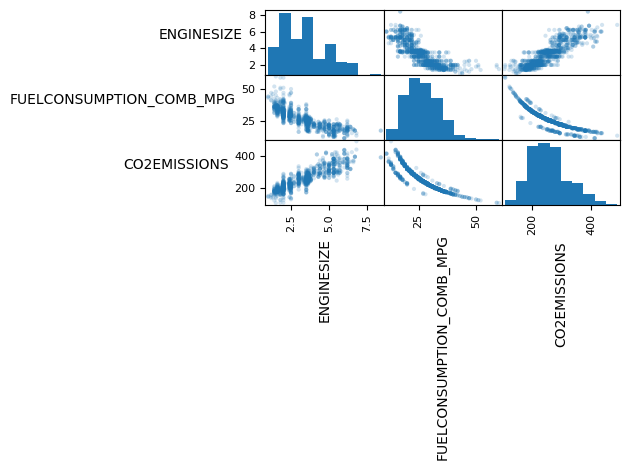

In [6]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()


In [11]:
X = df[['ENGINESIZE', 'FUELCONSUMPTION_COMB_MPG']].to_numpy()
y = df[['CO2EMISSIONS']].to_numpy()

*Using standard deviation.*

In [13]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)
pd.DataFrame(X_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


*Creating train and test datasets.*

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

*Building a multiple linear regression model.*

In [15]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)


Coefficients:  [[ 25.27339614 -37.4381472 ]]
Intercept:  [256.29072488]


In [16]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)


Coefficients:  [[17.8581369  -5.01502179]]
Intercept:  [329.1363967]


*Visualizing the model outputs.*

In [19]:
# 1. Separando as duas colunas diretamente
X1, X2 = X_test[:, 0], X_test[:, 1]

# 2. Criando a grade vetorial
x1_surf, x2_surf = np.meshgrid(
    np.linspace(X1.min(), X1.max(), 50),
    np.linspace(X2.min(), X2.max(), 50)
)

# 3. Calculando os valores de Y para o plano 3D
y_surf = regressor.intercept_ + regressor.coef_[0, 0] * x1_surf + regressor.coef_[0, 1] * x2_surf

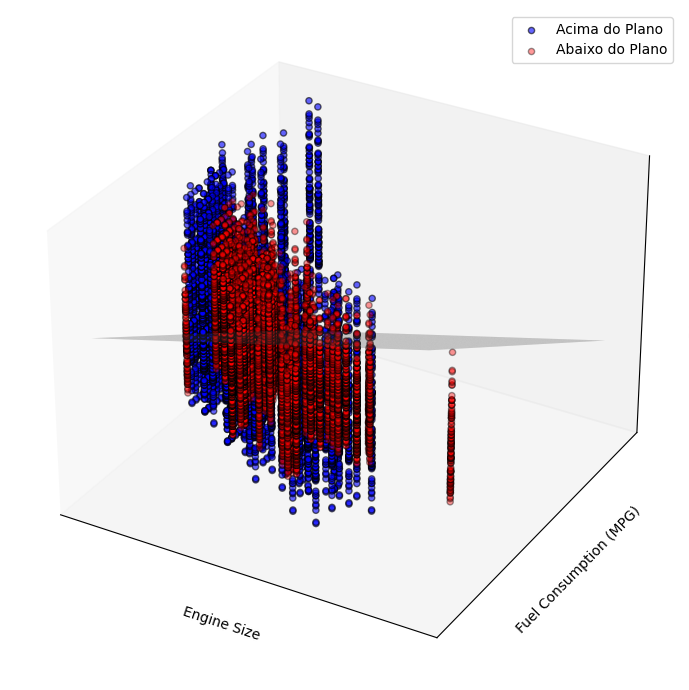

In [20]:
# 4. Predição para separar pontos acima e abaixo do plano
y_pred = regressor.predict(X_test)
above_plane = (y_test >= y_pred).flatten()
below_plane = (y_test < y_pred).flatten()

# 5. Criando a figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 6. Plot dos pontos e da superfície
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane], color='blue', label='Acima do Plano', alpha=0.6, ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane], color='red', label='Abaixo do Plano', alpha=0.4, ec='k')
ax.plot_surface(x1_surf, x2_surf, y_surf, color='gray', alpha=0.3)

# 7. Rótulos, ocultação de marcas e exibição
ax.set_xlabel('Engine Size')
ax.set_ylabel('Fuel Consumption (MPG)')
ax.set_zlabel('CO2 Emissions')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.legend()

plt.tight_layout()
plt.show()

*Plotting each variable separately for better visualization*

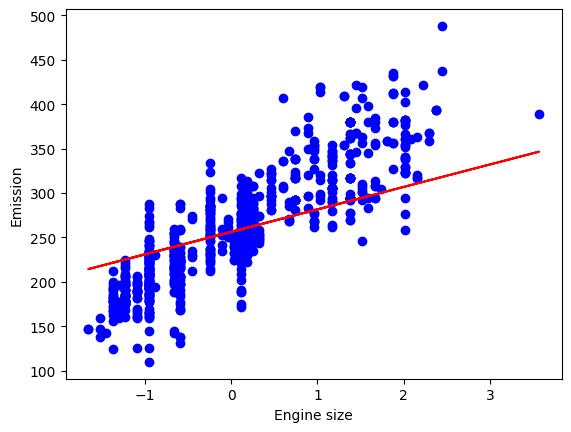

In [21]:
plt.scatter(X_train[:,0], y_train,  color='blue')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

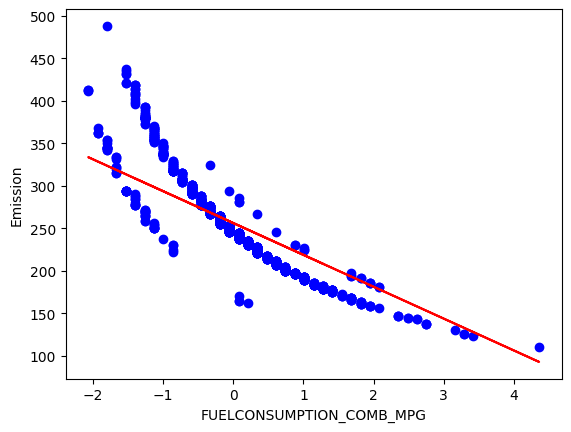

In [22]:
plt.scatter(X_train[:,1], y_train,  color='blue')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")
plt.show()

*Determining and printing the parameters for the best-fit linear regression line for CO2 emission with respect to engine size.*

In [26]:
X_train_1 = X_train[:, [0]]

regressor_1 = linear_model.LinearRegression()
regressor_1.fit(X_train_1, y_train)
coef_1 = regressor_1.coef_
intercept_1 = regressor_1.intercept_

print ('Coefficients: ', coef_1)
print ('Intercept: ', intercept_1)

Coefficients:  [[55.18408797]]
Intercept:  [256.77183014]


*Producing a scatterplot of CO2 emission against ENGINESIZE.*

Text(0, 0.5, 'Emission')

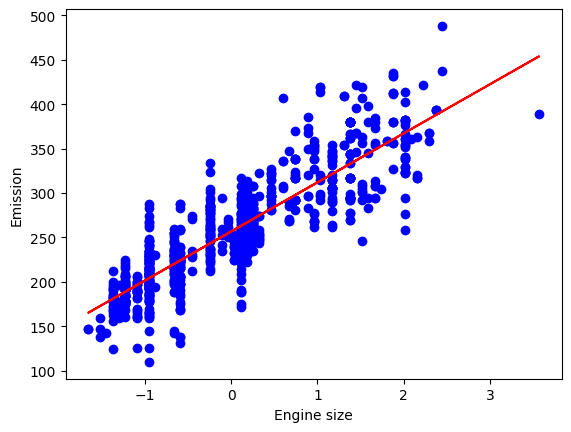

In [27]:
plt.scatter(X_train_1, y_train,  color='blue')
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

*Using FUELCONSUMPTION_COMB_MPG as the independent variable instead.*  

In [28]:
X_train_2 = X_train[:, [1]]

regressor_2 = linear_model.LinearRegression()
regressor_2.fit(X_train_2, y_train)
coef_2 = regressor_2.coef_
intercept_2 = regressor_2.intercept_

print ('Coefficients: ', coef_2)
print ('Intercept: ', intercept_2)

Coefficients:  [[-58.51827989]]
Intercept:  [256.09392179]


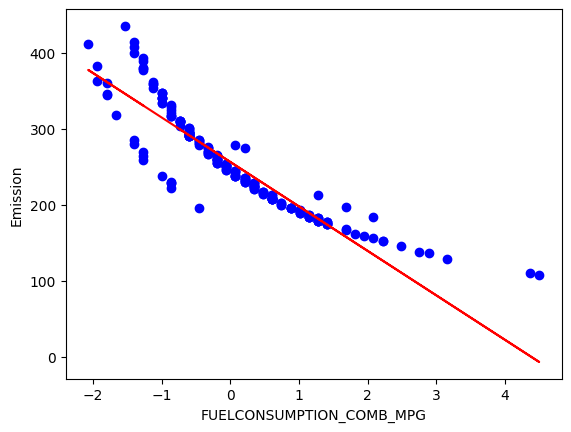

In [29]:
plt.scatter(X_test[:, 1], y_test, color='blue')
plt.plot(X_test[:, 1], coef_2[0] * X_test[:, 1] + intercept_2[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")
plt.show()